# `hormone_cycler` validation notebook

This notebook exercises the simulator across multiple cohort sizes, compares the resulting summary statistics with published values, and renders representative patient trajectories inline.

Primary reference families used by the package:

- Li et al. 2024 for age-stratified cycle length and irregularity
- Bull et al. 2019 for follicular/luteal phase timing and bleeding duration
- Stricker et al. 2006 for estradiol and progesterone reference medians
- Condition-specific studies documented in `src/hormone_cycler/hormone_constants.py`


In [1]:
from pathlib import Path
import html
import json
import sys

sys.path.insert(0, str(Path.cwd() / "src"))

from hormone_cycler.model import simulate_diary
from hormone_cycler.types import MedicalFactors
from hormone_cycler.validation import run_population_validation
from hormone_cycler.visualization import render_svg
from hormone_cycler.literature import CITATIONS

from IPython.display import HTML, SVG, display


def render_table(rows, columns):
    header = ''.join(f'<th style="padding:6px 10px;border-bottom:1px solid #ccc;text-align:left;">{html.escape(col)}</th>' for col in columns)
    body = []
    for row in rows:
        cells = ''.join(
            f'<td style="padding:6px 10px;border-bottom:1px solid #eee;">{html.escape(str(row.get(col, "")))}</td>'
            for col in columns
        )
        body.append(f'<tr>{cells}</tr>')
    return HTML(
        '<table style="border-collapse:collapse;font-family:Arial,sans-serif;font-size:13px;">'
        f'<thead><tr>{header}</tr></thead><tbody>{"".join(body)}</tbody></table>'
    )


def metric_bar_chart(metrics, title):
    width = 980
    bar_height = 18
    label_width = 320
    chart_width = 560
    height = 70 + bar_height * len(metrics)
    rows = []
    for idx, metric in enumerate(metrics):
        y = 50 + idx * bar_height
        expected = float(metric['expected'])
        observed = float(metric['observed'])
        lower = float(metric['lower_bound'])
        upper = float(metric['upper_bound'])
        span = max(upper - lower, 1e-6)
        scaled_lower = label_width
        scaled_upper = label_width + chart_width
        scaled_expected = label_width + chart_width * (expected - lower) / span
        scaled_observed = label_width + chart_width * (observed - lower) / span
        color = '#2f855a' if metric['passed'] else '#c53030'
        rows.append(f'<text x="10" y="{y + 13}" font-size="12" fill="#1f2933">{html.escape(metric["name"])}</text>')
        rows.append(f'<line x1="{scaled_lower:.1f}" y1="{y + 8}" x2="{scaled_upper:.1f}" y2="{y + 8}" stroke="#cbd5e0" stroke-width="6" stroke-linecap="round"/>')
        rows.append(f'<line x1="{scaled_expected:.1f}" y1="{y + 2}" x2="{scaled_expected:.1f}" y2="{y + 14}" stroke="#1f2933" stroke-width="2"/>')
        rows.append(f'<circle cx="{scaled_observed:.1f}" cy="{y + 8}" r="5" fill="{color}"/>')
        rows.append(f'<text x="{label_width + chart_width + 12}" y="{y + 13}" font-size="12" fill="#4a5568">obs={observed:.3f}; expected={expected:.3f}</text>')
    svg = '\n'.join([
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#fffdf8"/>',
        f'<text x="10" y="24" font-size="18" font-family="Georgia, serif" fill="#2d3748">{html.escape(title)}</text>',
        '<text x="10" y="42" font-size="12" fill="#4a5568">Green points passed the validation window; red points fell outside it.</text>',
        *rows,
        '</svg>'
    ])
    return SVG(svg)


In [2]:
cohort_sizes = [500, 2000, 10000]
days = 365
seed = 7

reports = {}
for size in cohort_sizes:
    reports[size] = run_population_validation(
        num_patients=size,
        days=days,
        seed=seed,
        include_subgroups=(size == cohort_sizes[-1]),
    )

summary_rows = []
for size in cohort_sizes:
    report = reports[size]
    baseline_metrics = report['baseline_metrics']
    summary_rows.append({
        'patients': size,
        'days': days,
        'baseline_passed': report['baseline_passed'],
        'baseline_metric_count': len(baseline_metrics),
        'failed_metrics': sum(1 for metric in baseline_metrics if not metric['passed']),
    })

render_table(summary_rows, ['patients', 'days', 'baseline_passed', 'baseline_metric_count', 'failed_metrics'])


patients,days,baseline_passed,baseline_metric_count,failed_metrics
500,365,False,33,2
2000,365,True,33,0
10000,365,True,33,0


metric,observed,expected,lower,upper,passed,citation
cycle_mean_<20,30.566,30.300,29.650,30.950,True,Li et al. 2024
cycle_irregularity_<20,0.307,0.312,0.269,0.355,True,Li et al. 2024
cycle_mean_20-24,30.007,30.000,29.500,30.500,True,Li et al. 2024
cycle_irregularity_20-24,0.195,0.204,0.164,0.244,True,Li et al. 2024
cycle_mean_25-29,28.983,29.100,28.600,29.600,True,Li et al. 2024
cycle_irregularity_25-29,0.162,0.164,0.124,0.204,True,Li et al. 2024
cycle_mean_30-34,28.778,28.800,28.300,29.300,True,Li et al. 2024
cycle_irregularity_30-34,0.146,0.147,0.107,0.187,True,Li et al. 2024
cycle_mean_35-39,28.682,28.800,28.300,29.300,True,Li et al. 2024
cycle_irregularity_35-39,0.160,0.159,0.119,0.199,True,Li et al. 2024


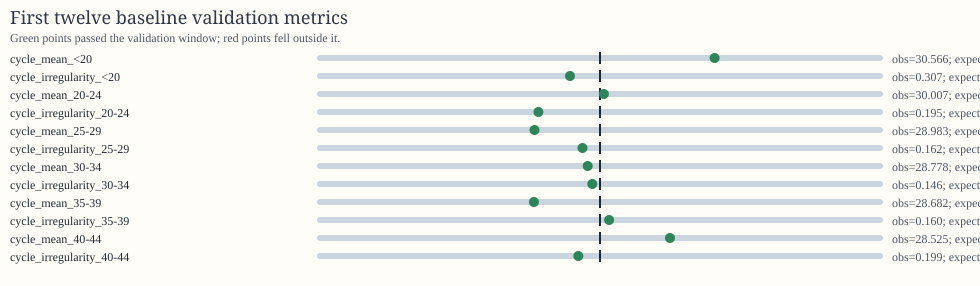

In [3]:
full_report = reports[10000]
baseline_rows = [
    {
        'metric': metric['name'],
        'observed': f"{metric['observed']:.3f}" if isinstance(metric['observed'], (int, float)) else metric['observed'],
        'expected': f"{metric['expected']:.3f}" if isinstance(metric['expected'], (int, float)) else metric['expected'],
        'lower': f"{metric['lower_bound']:.3f}" if isinstance(metric['lower_bound'], (int, float)) else metric['lower_bound'],
        'upper': f"{metric['upper_bound']:.3f}" if isinstance(metric['upper_bound'], (int, float)) else metric['upper_bound'],
        'passed': metric['passed'],
        'citation': metric['citation']['short_name'],
    }
    for metric in full_report['baseline_metrics']
]

display(render_table(baseline_rows, ['metric', 'observed', 'expected', 'lower', 'upper', 'passed', 'citation']))
display(metric_bar_chart(full_report['baseline_metrics'][:12], 'First twelve baseline validation metrics'))


In [4]:
subgroup_rows = []
for name, payload in full_report['subgroup_analysis']['subgroups'].items():
    summary = payload['summary']
    subgroup_rows.append({
        'subgroup': name,
        'passed': payload['passed'],
        'mean_cycle_days': summary['mean_cycle_days'],
        'ovulation_rate': summary['ovulation_rate'],
        'mean_bleeding_days': summary['mean_bleeding_days'],
        'irregularity_rate': summary['irregularity_rate'],
        'amenorrhea_rate': summary['amenorrhea_rate'],
    })

render_table(subgroup_rows, ['subgroup', 'passed', 'mean_cycle_days', 'ovulation_rate', 'mean_bleeding_days', 'irregularity_rate', 'amenorrhea_rate'])


subgroup,passed,mean_cycle_days,ovulation_rate,mean_bleeding_days,irregularity_rate,amenorrhea_rate
pcos,True,36.107,0.426,5.103,0.472,0.0
cyclic_ocp,True,28.0,0.0,4.004,0.0,0.0
continuous_ocp,True,28.0,0.0,0.961,0.0,0.554
hormonal_iud,True,29.634,0.8,2.075,0.248,0.174
copper_iud,True,29.458,0.909,5.878,0.245,0.0
perimenopause,True,30.262,0.524,5.92,0.404,0.0
peri_menarche,True,32.863,0.549,5.815,0.372,0.0
dysmenorrhea,True,29.267,0.909,5.206,0.249,0.0


baseline

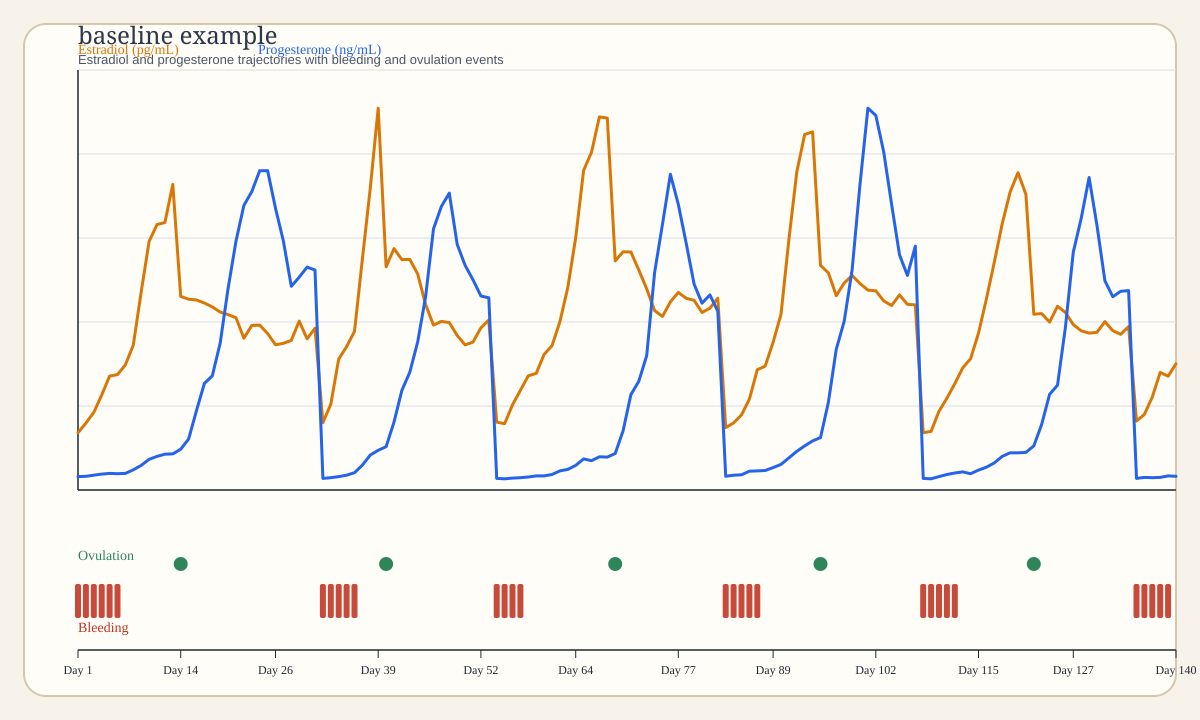

pcos

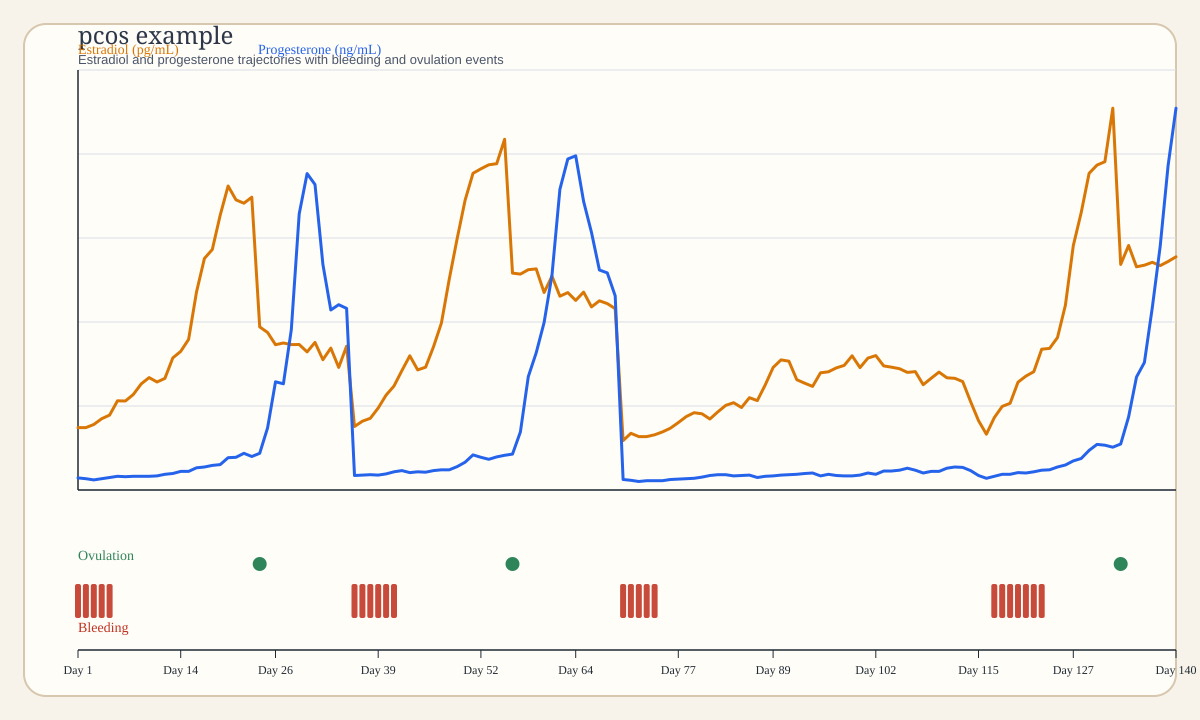

hormonal_iud

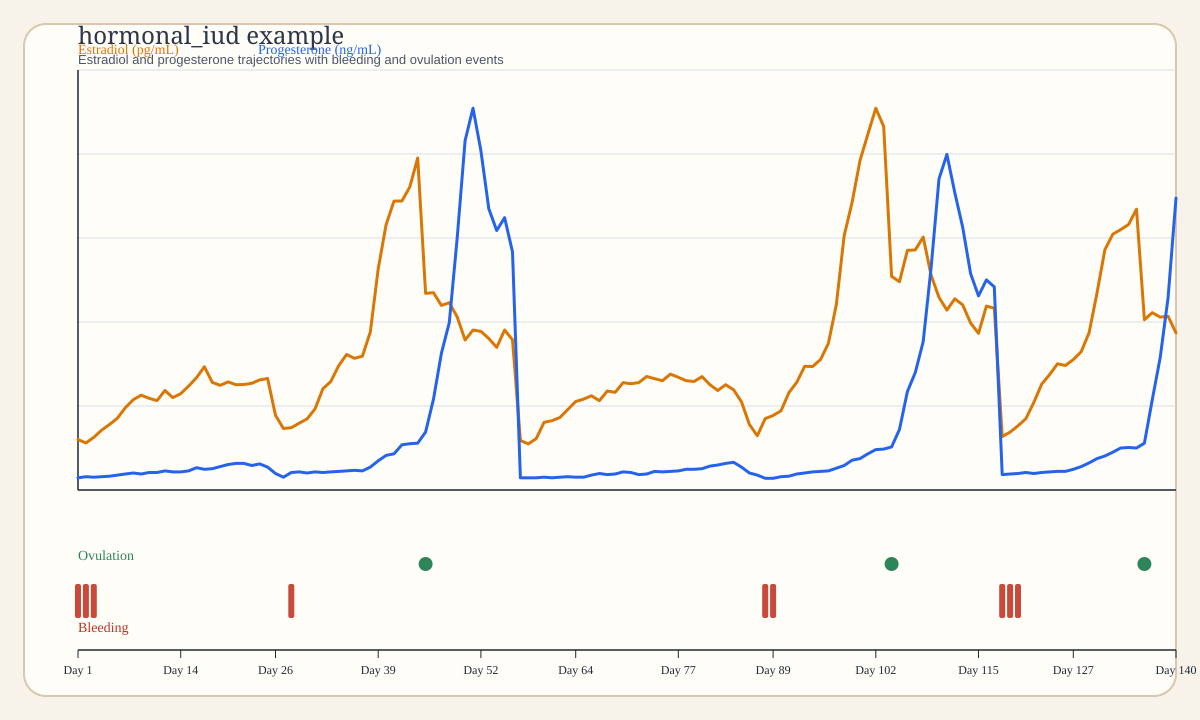

continuous_ocp

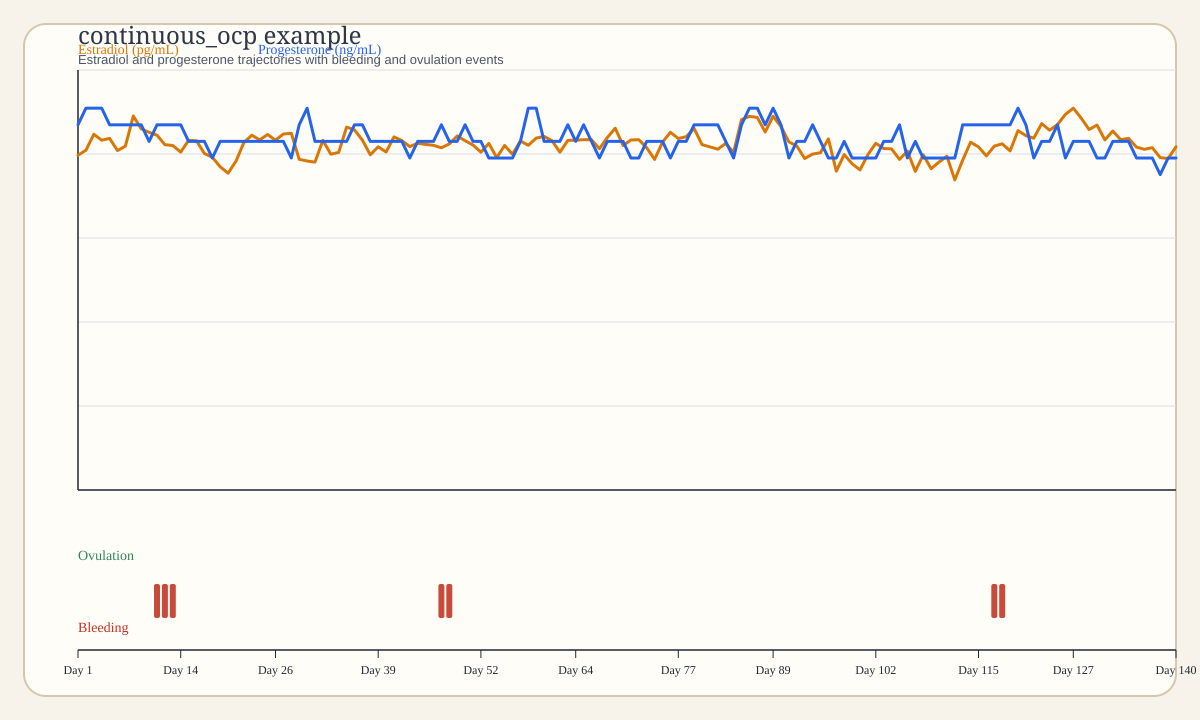

In [5]:
example_profiles = {
    'baseline': MedicalFactors(),
    'pcos': MedicalFactors(pcos=True),
    'hormonal_iud': MedicalFactors(hormonal_iud=True),
    'continuous_ocp': MedicalFactors(oral_contraceptive_mode='continuous'),
}

for index, (label, factors) in enumerate(example_profiles.items(), start=1):
    result = simulate_diary(days=140, age_years=29, medical_factors=factors, seed=100 + index, patient_id=label)
    display(HTML(f'<h3 style="font-family:Georgia,serif;">{html.escape(label)}</h3>'))
    display(SVG(render_svg(result.diary, title=f'{label} example')))


In [6]:
output_path = Path('examples/reports/notebook_validation_report.json')
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(json.dumps(full_report, indent=2), encoding='utf-8')
print(f'Wrote notebook validation report to {output_path}')

citation_rows = [
    {'key': key, 'short_name': citation.short_name, 'url': citation.url}
    for key, citation in CITATIONS.items()
]
render_table(citation_rows, ['key', 'short_name', 'url'])


Wrote notebook validation report to examples/reports/notebook_validation_report.json


key,short_name,url
li_2024_awhs,Li et al. 2024,https://pmc.ncbi.nlm.nih.gov/articles/PMC11228203/
bull_2019_natural_cycles,Bull et al. 2019,https://www.nature.com/articles/s41746-019-0152-7
stricker_2006_reference,Stricker et al. 2006,https://pubmed.ncbi.nlm.nih.gov/16776638/
fraser_2007_bleeding,Fraser et al. 2011,https://pubmed.ncbi.nlm.nih.gov/22045566/
mortimer_2025_pcos,Mortimer et al. 2025,https://pubmed.ncbi.nlm.nih.gov/39960584/
doi_2005_pcos_hormones,Doi et al. 2005,https://pubmed.ncbi.nlm.nih.gov/16117815/
venturoli_1987_menarche,Venturoli et al. 1987,https://pubmed.ncbi.nlm.nih.gov/3127843/
santoro_2008_perimenopause,Santoro et al. 2008,https://pmc.ncbi.nlm.nih.gov/articles/PMC3414596/
edelman_2014_ocp,Edelman et al. 2014,https://pubmed.ncbi.nlm.nih.gov/25072731/
xiao_1995_lng_iud,Xiao et al. 1995,https://pubmed.ncbi.nlm.nih.gov/7554977/
